In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from scipy.stats import probplot
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
# hide warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------- ----------------------------- 2.6/9.5 MB 17.0 MB/s eta 0:00:01
   -------------- ------------------------- 3.4/9.5 MB 10.3 MB/s eta 0:00:01
   ----------------- ---------------------- 4.2/9.5 MB 7.5 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.5 MB 6.3 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.5 MB 5.6 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.5 MB 4.9 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.5 MB 4.7 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 4.6 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.5 MB 4.3 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.5 MB 3.9 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.5 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 3.8 MB/s eta 0:00:01
   --------------


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [123]:
data=pd.read_csv("CarPrice_Assignment.csv")
data["symboling"].value_counts()

symboling
 0    67
 1    54
 2    32
 3    27
-1    22
-2     3
Name: count, dtype: int64

In [105]:
data.shape
print(data.info())
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

The dataset had no missing values.

Draw some basic plot like histogram,barplot and draw scatter plot for check the relationship between predictor variables and target variables.

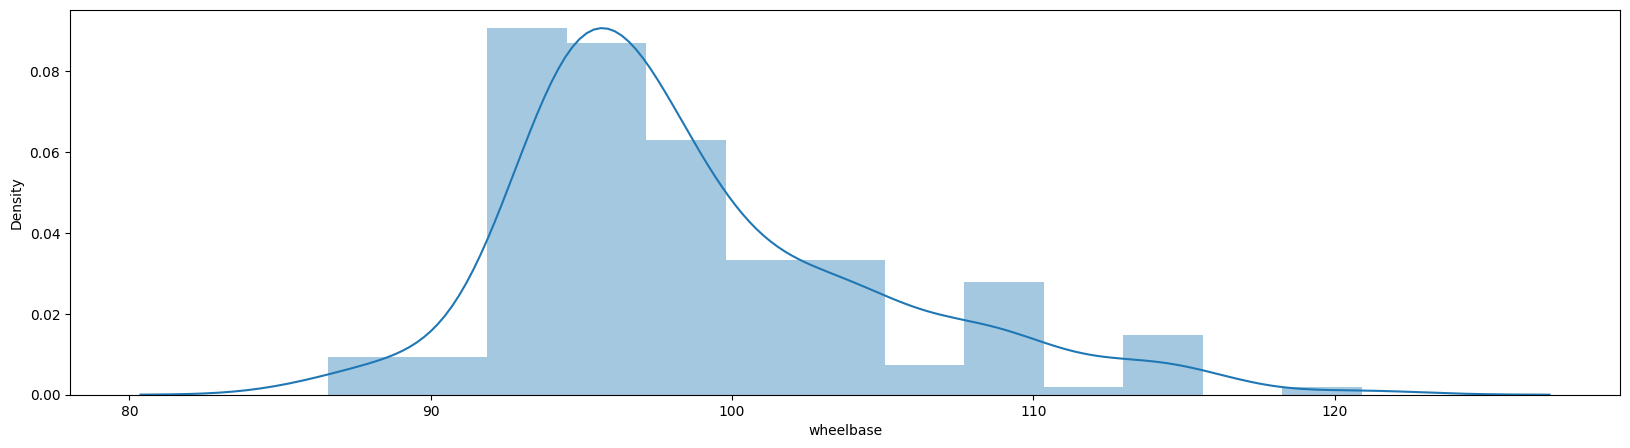

None


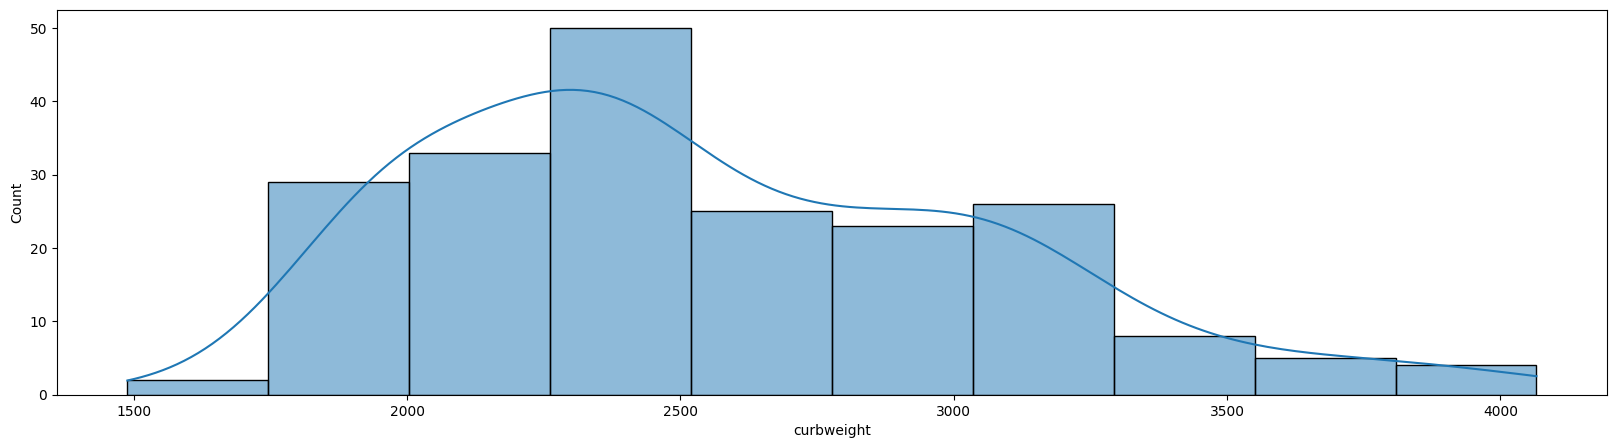

None


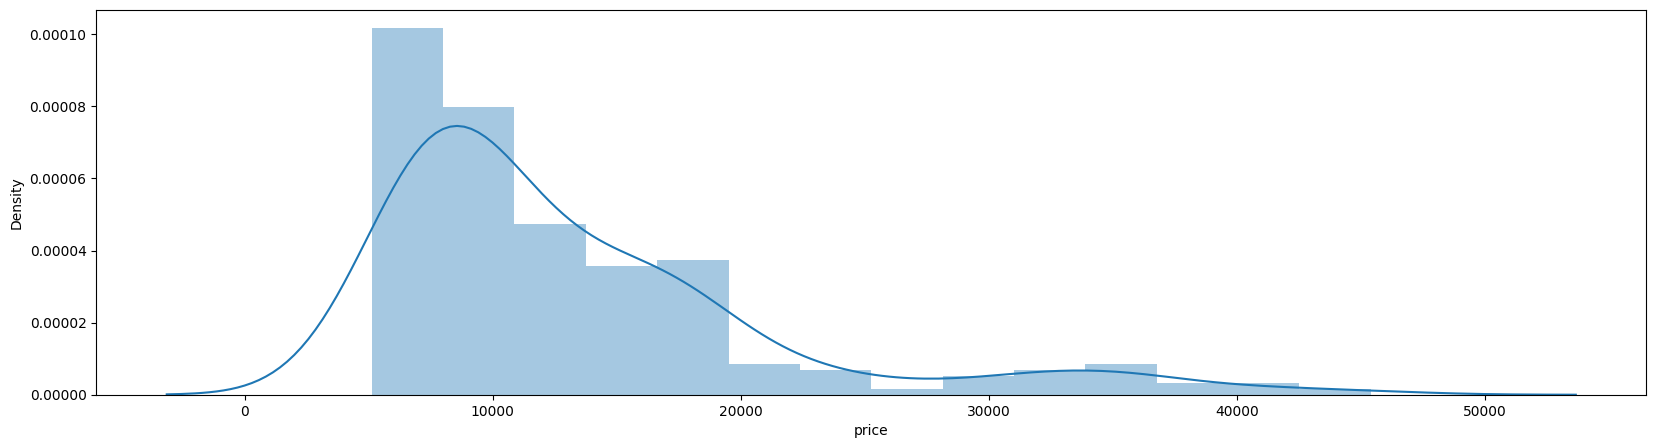

In [10]:
plt.figure(figsize=(20,5))
sns.distplot(data['wheelbase'])
print(plt.show())
plt.figure(figsize=(20,5))
sns.histplot(data['curbweight'],kde=True)
print(plt.show())
plt.figure(figsize=(20,5))
sns.distplot(data['price'],kde=True)
plt.show()


Axes(0.125,0.11;0.775x0.77)


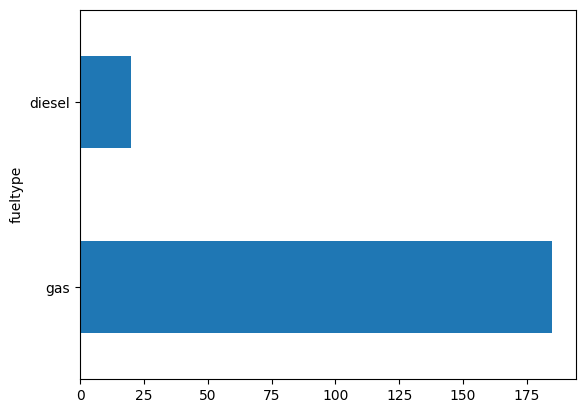

In [106]:
print(data["fueltype"].value_counts().plot(kind="barh"))

Axes(0.125,0.11;0.775x0.77)


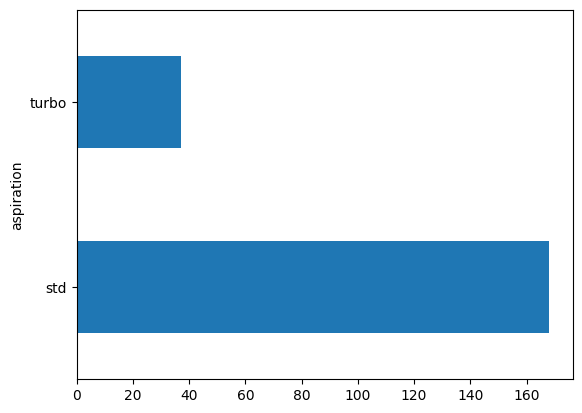

In [12]:
print(data["aspiration"].value_counts().plot(kind="barh"))

Here Car variable  have many model name of car. So we combine the same model and denote its car company name.

CarName
toyota         32
nissan         18
mazda          17
mitsubishi     13
honda          13
subaru         12
volkswagen     12
volvo          11
peugeot        11
dodge           9
buick           8
bmw             8
audi            7
plymouth        7
saab            6
porsche         5
isuzu           4
alfa-romero     3
chevrolet       3
jaguar          3
renault         2
mercury         1
Name: count, dtype: int64


<Axes: ylabel='count'>

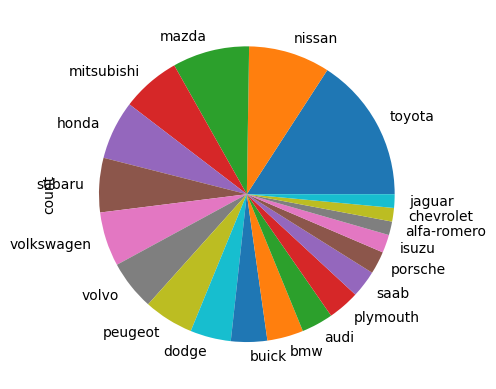

In [124]:
data['CarName'] = data['CarName'].apply(lambda x: x.split(" ")[0])
data.loc[(data['CarName'] == "vw") | 
         (data['CarName'] == "vokswagen")
         , 'CarName'] = 'volkswagen'

# porsche
data.loc[data['CarName'] == "porcshce", 'CarName'] = 'porsche'

# toyota
data.loc[data['CarName'] == "toyouta", 'CarName'] = 'toyota'

# nissan
data.loc[data['CarName'] == "Nissan", 'CarName'] = 'nissan'

# mazda
data.loc[data['CarName'] == "maxda", 'CarName'] = 'mazda'

print(data["CarName"].value_counts())

data['CarName'].value_counts().head(20).plot(kind="pie")


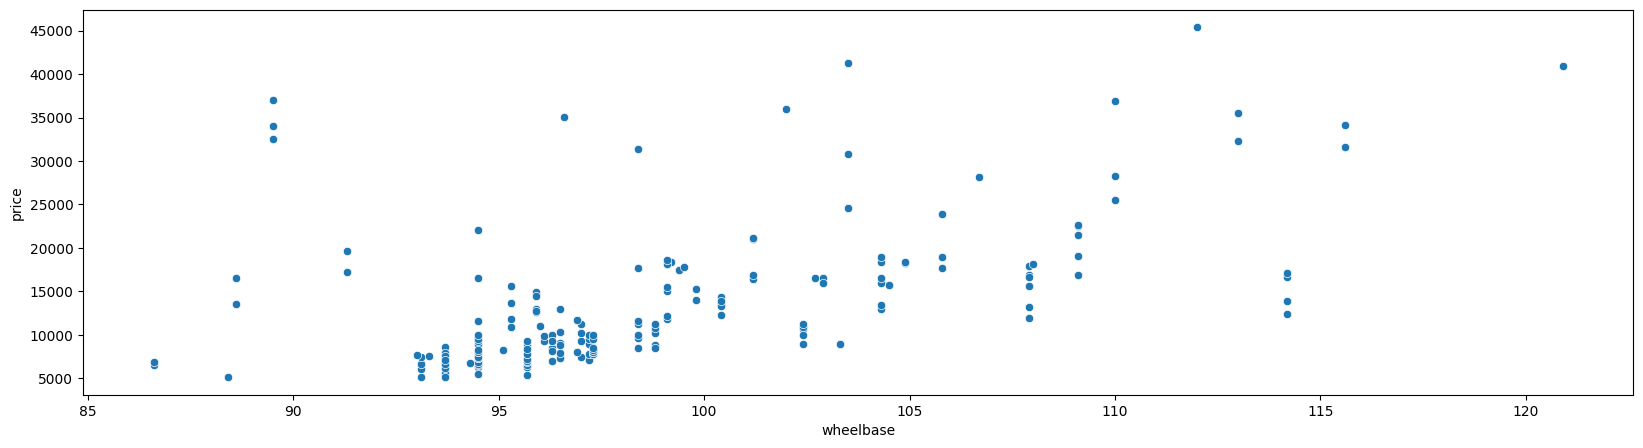

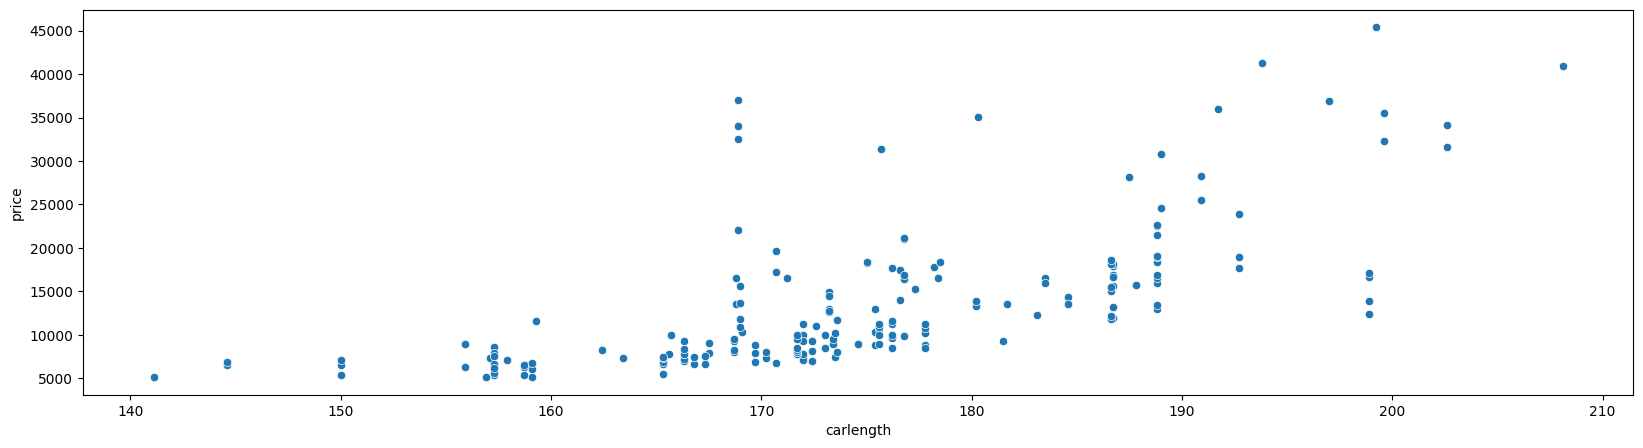

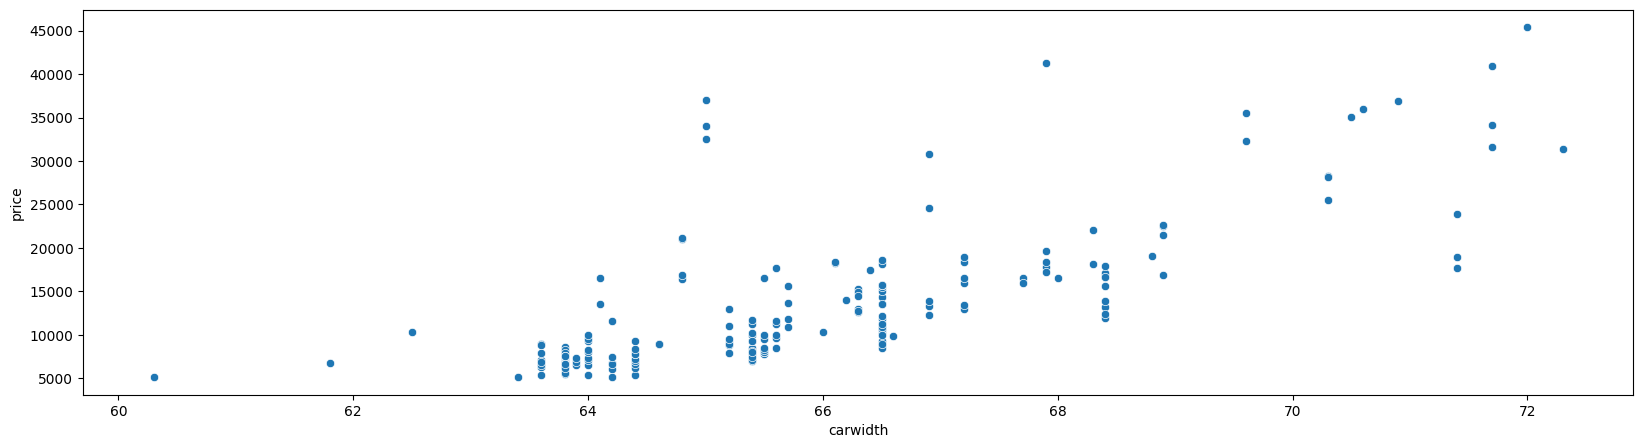

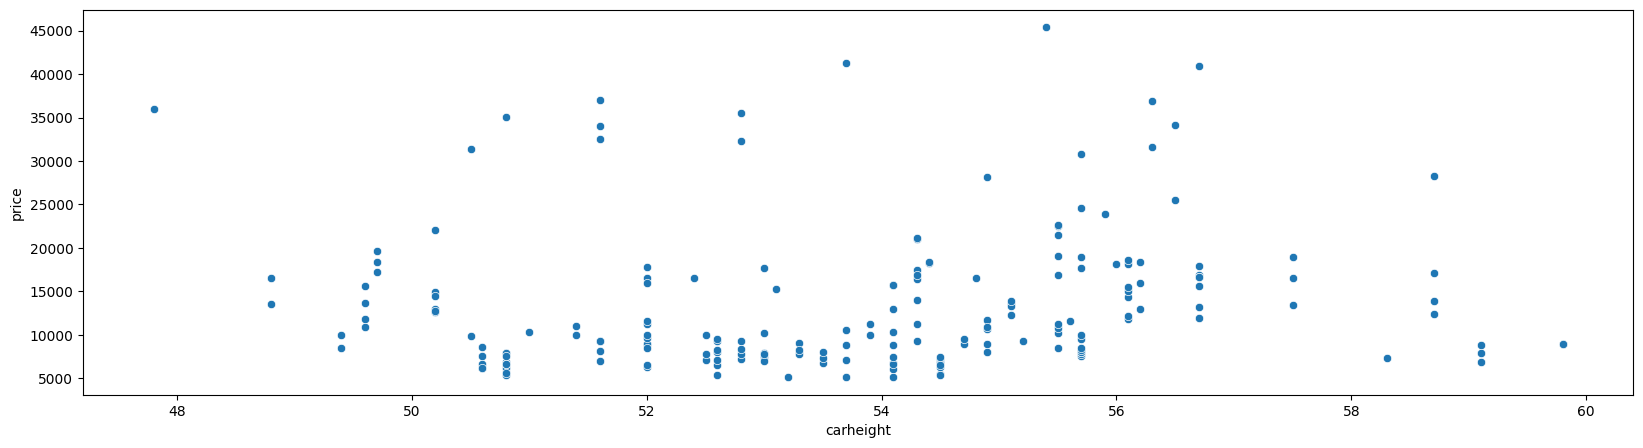

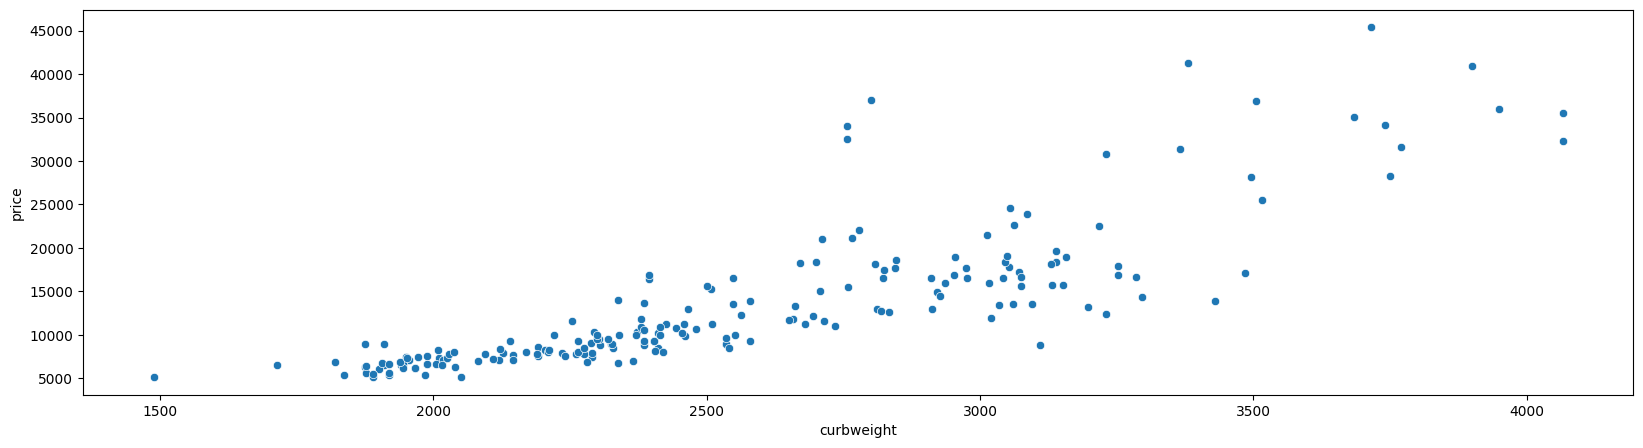

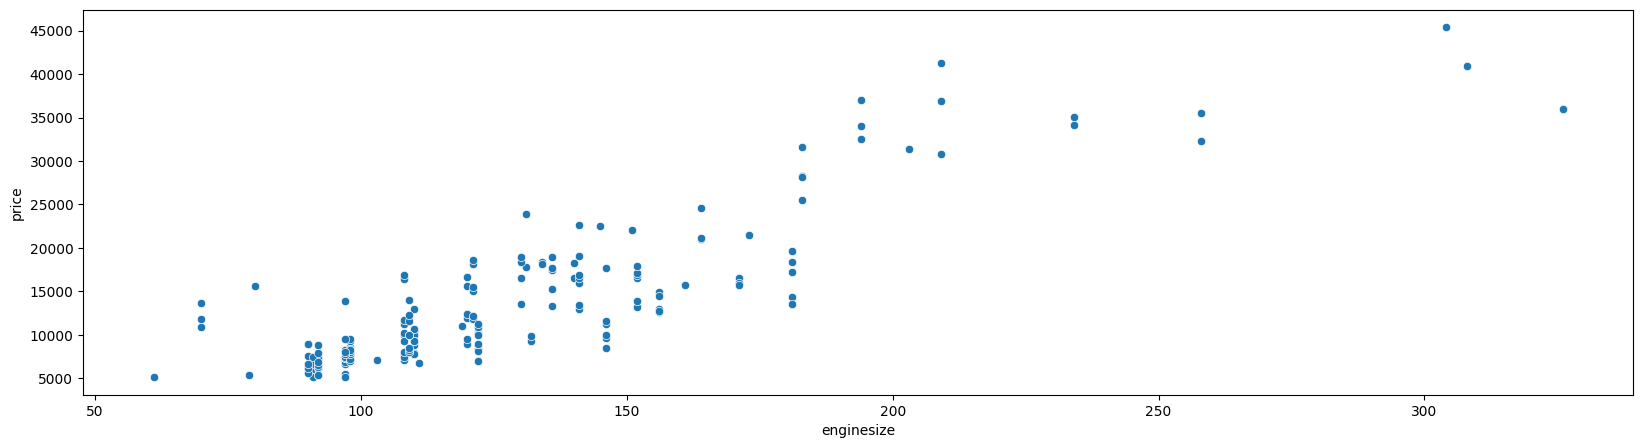

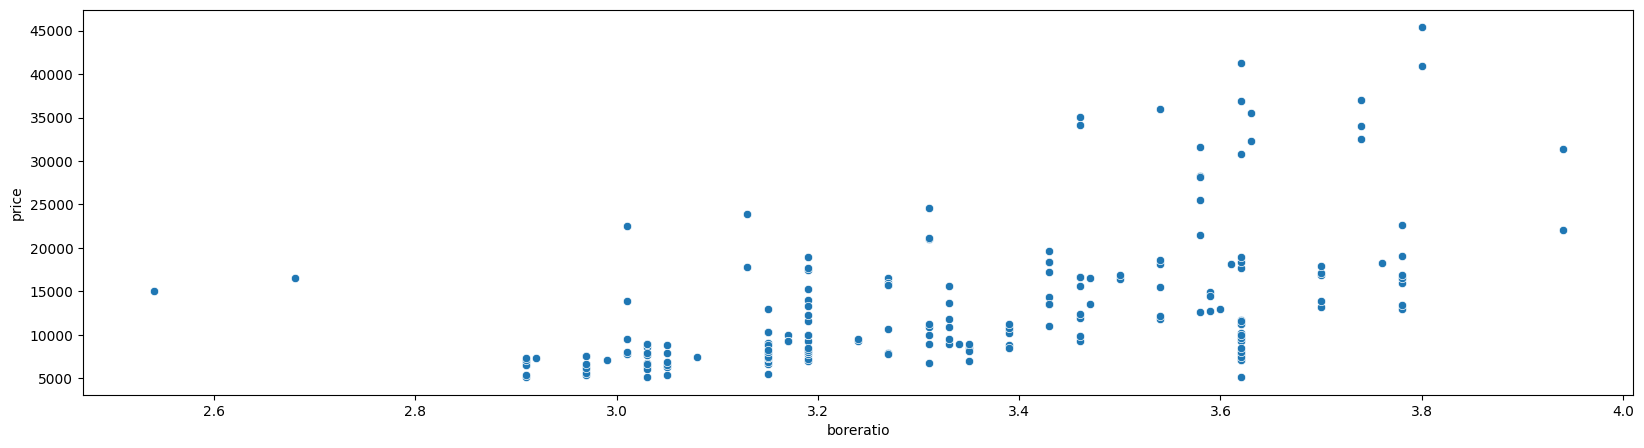

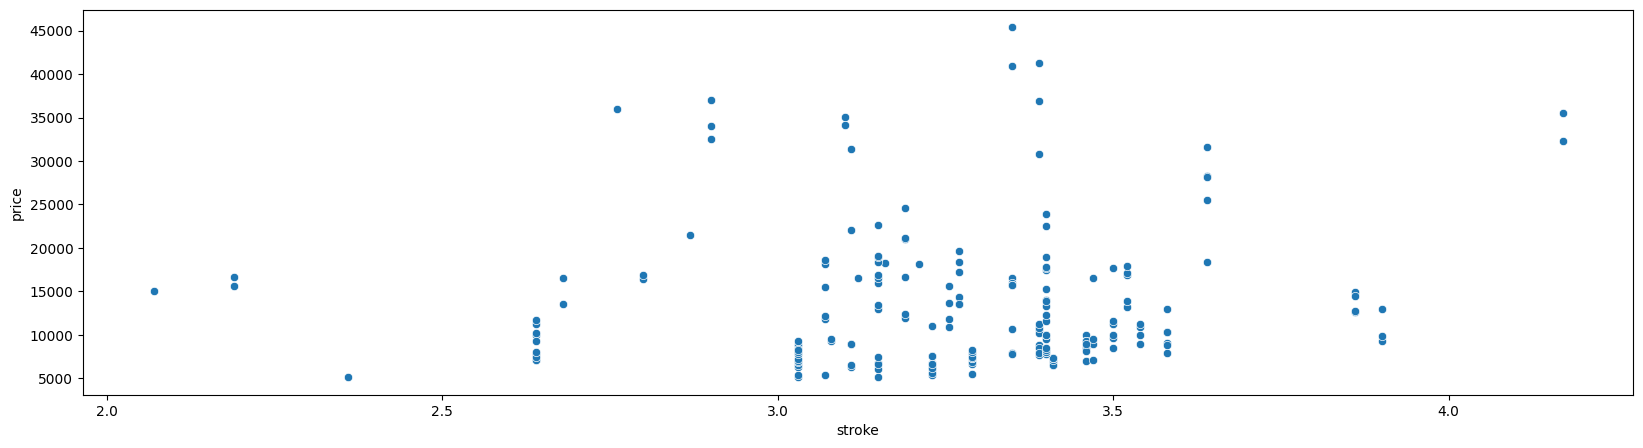

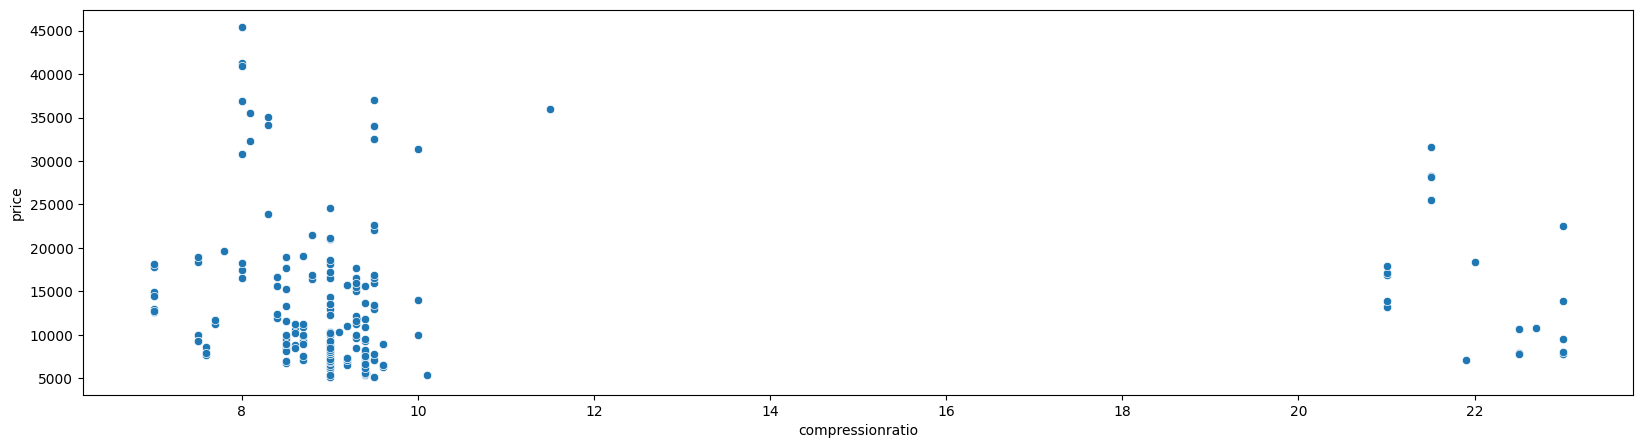

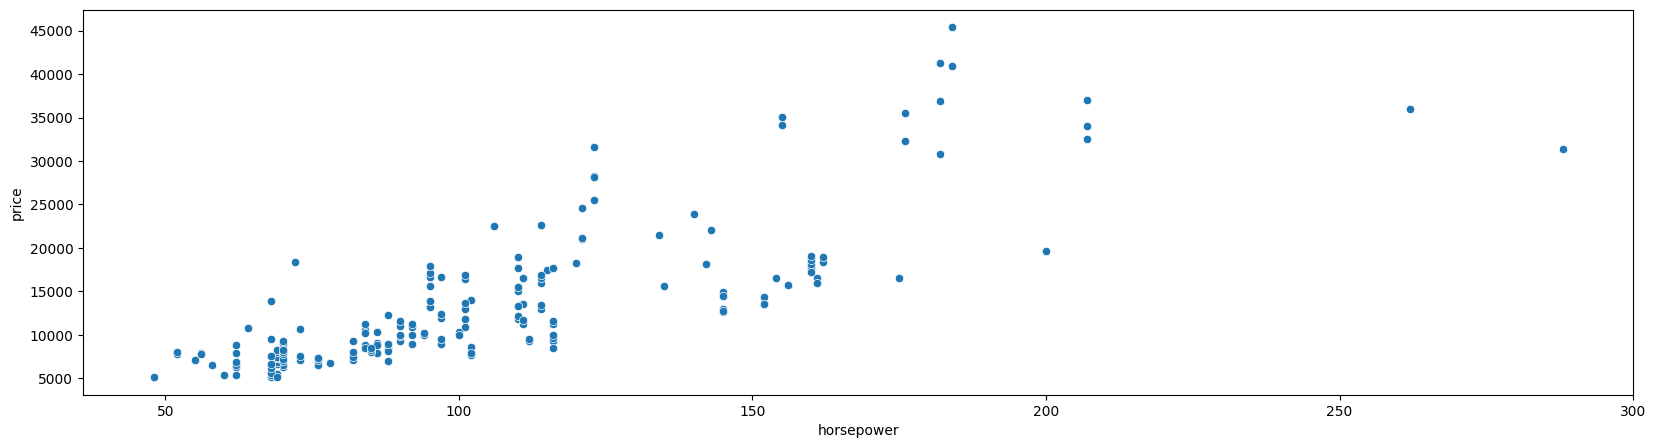

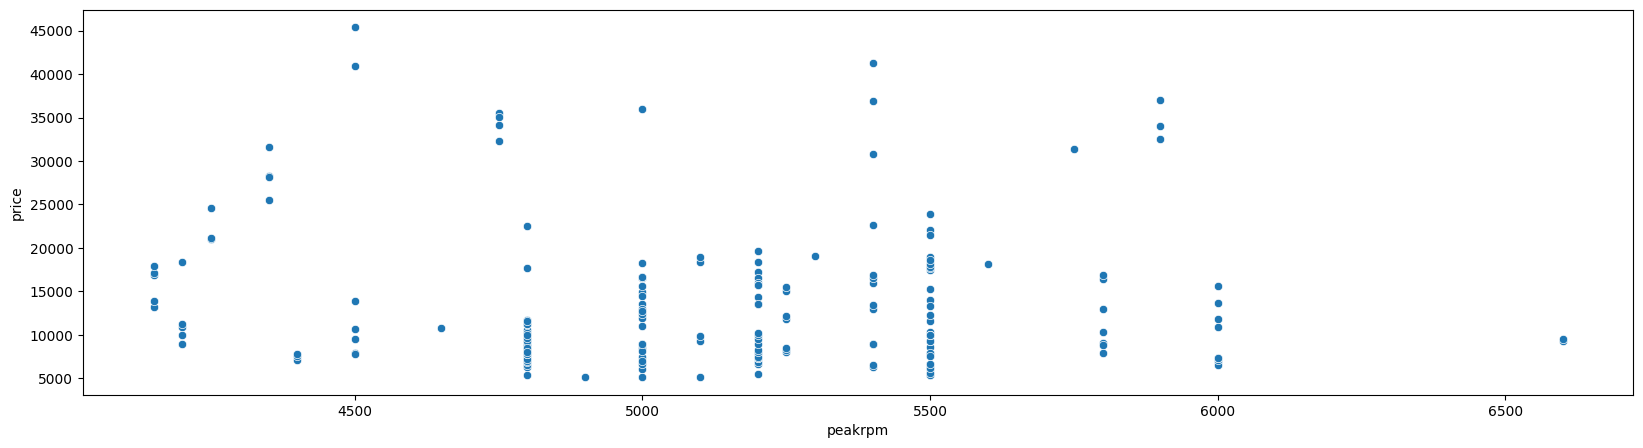

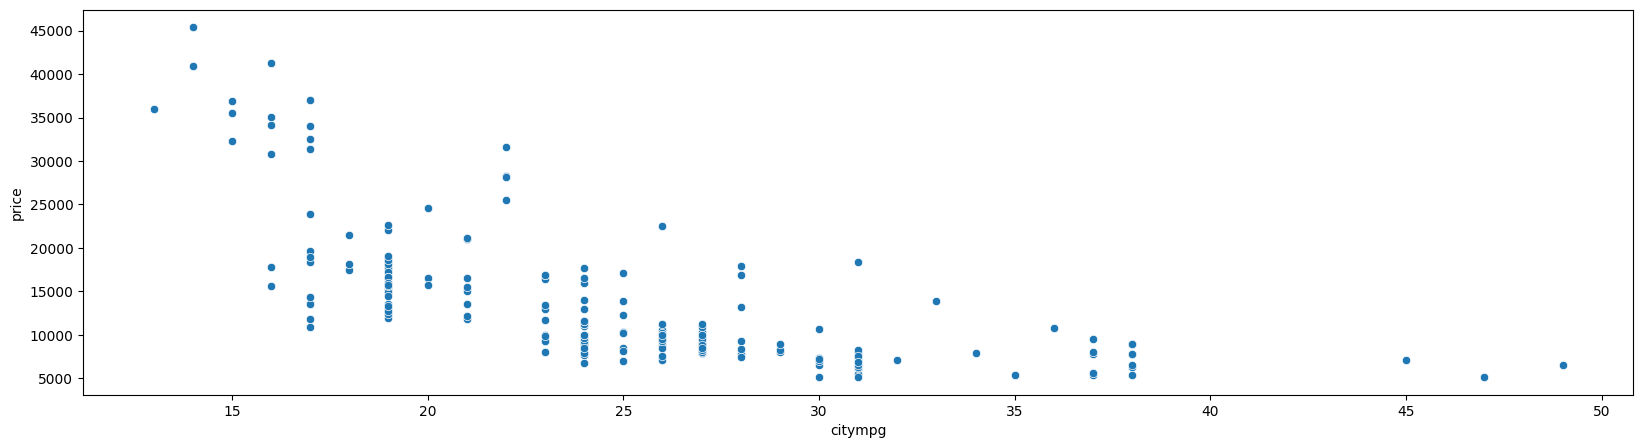

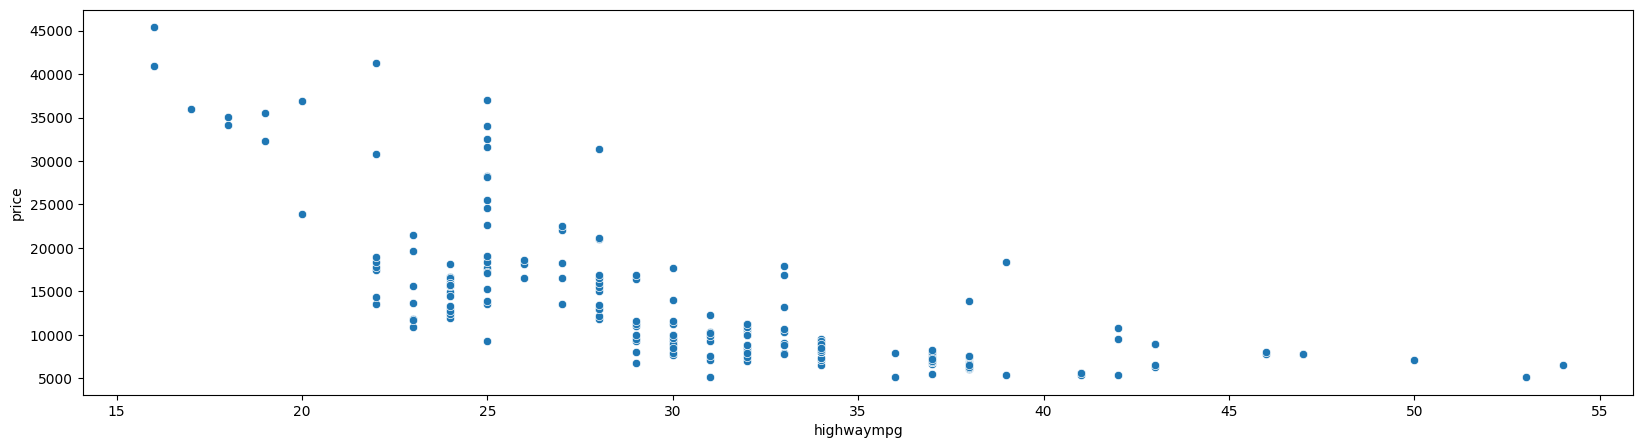

In [108]:
vars_numeric = data.select_dtypes(include=['float', 'int'])
vars_numeric.head()
vars_numeric = vars_numeric.drop(['symboling','car_ID','price'], axis=1)
vars_numeric.head()
for col in vars_numeric:
    plt.figure(figsize=(20,5))
    sns.scatterplot(data=data,x=data[col],y="price")
    

we see target variable and predictor variables have linear relationship.

Let us find the correlation for finding the correlated pairs.

                  wheelbase  carlength  carwidth  carheight  curbweight  \
wheelbase          1.000000   0.874587  0.795144   0.589435    0.776386   
carlength          0.874587   1.000000  0.841118   0.491029    0.877728   
carwidth           0.795144   0.841118  1.000000   0.279210    0.867032   
carheight          0.589435   0.491029  0.279210   1.000000    0.295572   
curbweight         0.776386   0.877728  0.867032   0.295572    1.000000   
enginesize         0.569329   0.683360  0.735433   0.067149    0.850594   
boreratio          0.488750   0.606454  0.559150   0.171071    0.648480   
stroke             0.160959   0.129533  0.182942  -0.055307    0.168790   
compressionratio   0.249786   0.158414  0.181129   0.261214    0.151362   
horsepower         0.353294   0.552623  0.640732  -0.108802    0.750739   
peakrpm           -0.360469  -0.287242 -0.220012  -0.320411   -0.266243   
citympg           -0.470414  -0.670909 -0.642704  -0.048640   -0.757414   
highwaympg        -0.5440

<Axes: >

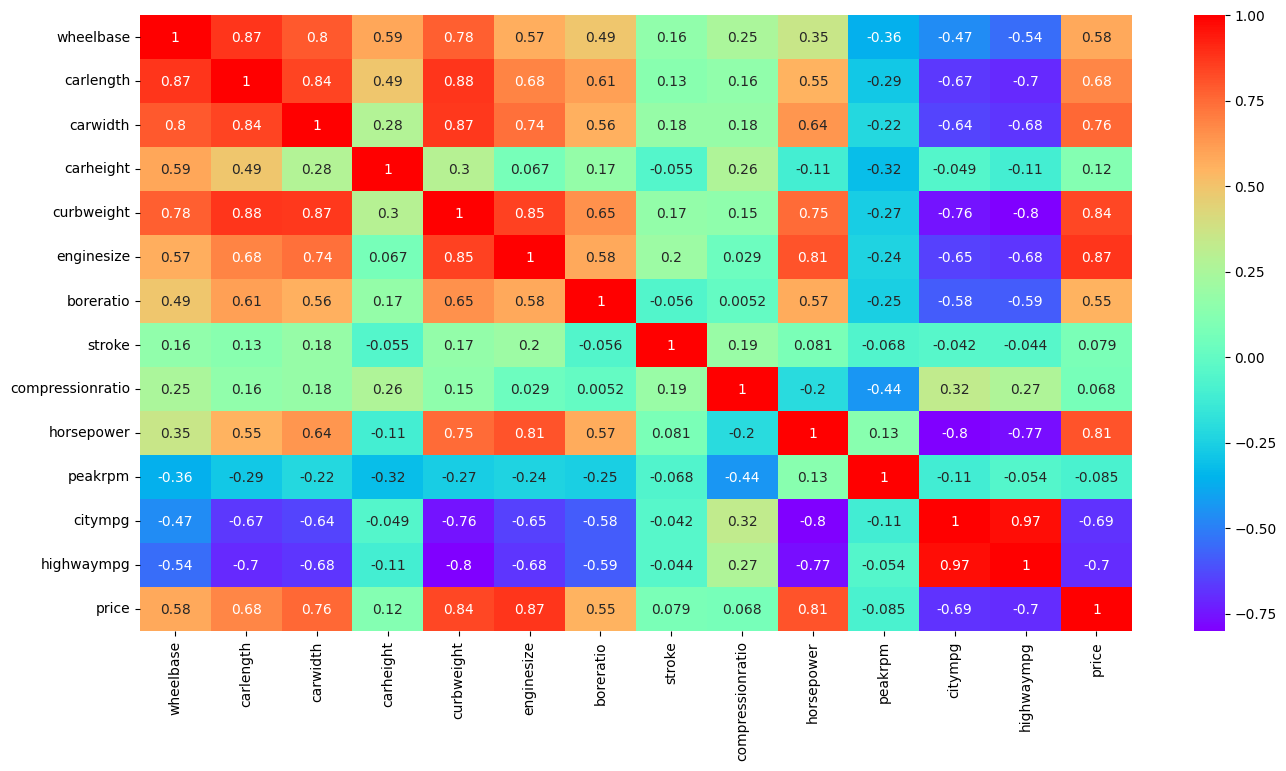

In [125]:
numeric_var=data.select_dtypes(include=["int","float"])
numeric_var
numeric_var= numeric_var.drop(['symboling','car_ID'], axis=1)
cor = numeric_var.corr()
print(cor)
plt.figure(figsize=(16,8))
sns.heatmap(cor,cmap="rainbow",annot=True)

Correlation of price with independent variables:

Price is highly (positively) correlated with wheelbase, carlength, carwidth, curbweight, enginesize, horsepower (notice how all of these variables represent the size/weight/engine power of the car)

Price is negatively correlated to citympg and highwaympg (-0.70 approximately). This suggest that cars having high mileage may fall in the 'economy' cars category, and are priced lower (think Maruti Alto/Swift type of cars, which are designed to be affordable by the middle class, who value mileage more than horsepower/size of car etc.)

Correlation among independent variables:

Many independent variables are highly correlated (look at the top-left part of matrix): wheelbase, carlength, curbweight, enginesize etc. are all measures of 'size/weight', and are positively correlated
Thus, while building the model, we'll have to pay attention to multicollinearity (especially linear models, such as linear  regression, suffer more from multicollinearity).

In [109]:
data.iloc[:,:25]

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg
0,1,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27
1,2,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27
2,3,1,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26
3,4,2,audi,gas,std,four,sedan,fwd,front,99.8,...,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30
4,5,2,audi,gas,std,four,sedan,4wd,front,99.4,...,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo,gas,std,four,sedan,rwd,front,109.1,...,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28
201,202,-1,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25
202,203,-1,volvo,gas,std,four,sedan,rwd,front,109.1,...,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23
203,204,-1,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,six,145,idi,3.01,3.40,23.0,106,4800,26,27


In [126]:
data["symboling"].value_counts()

symboling
 0    67
 1    54
 2    32
 3    27
-1    22
-2     3
Name: count, dtype: int64

Using one hot encoding we encoded the categorical variables.

In [127]:
data.drop("car_ID",axis=1,inplace=True)


In [128]:

data["symboling"] = data["symboling"].replace([-1, -2], [4, 5])

categorical_vars = [
    'CarName','fueltype','aspiration','doornumber','carbody',
    'drivewheel','enginelocation','enginetype','cylindernumber',
    'fuelsystem','symboling'
]

data = pd.get_dummies(data, columns=categorical_vars, drop_first=True).astype(float)

print(data.head())

   wheelbase  carlength  carwidth  carheight  curbweight  enginesize  \
0       88.6      168.8      64.1       48.8      2548.0       130.0   
1       88.6      168.8      64.1       48.8      2548.0       130.0   
2       94.5      171.2      65.5       52.4      2823.0       152.0   
3       99.8      176.6      66.2       54.3      2337.0       109.0   
4       99.4      176.6      66.4       54.3      2824.0       136.0   

   boreratio  stroke  compressionratio  horsepower  ...  fuelsystem_idi  \
0       3.47    2.68               9.0       111.0  ...             0.0   
1       3.47    2.68               9.0       111.0  ...             0.0   
2       2.68    3.47               9.0       154.0  ...             0.0   
3       3.19    3.40              10.0       102.0  ...             0.0   
4       3.19    3.40               8.0       115.0  ...             0.0   

   fuelsystem_mfi  fuelsystem_mpfi  fuelsystem_spdi  fuelsystem_spfi  \
0             0.0              1.0          

In [112]:
data

,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,...,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi,symboling_1,symboling_2,symboling_3,symboling_4,symboling_5
0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,9.0,111.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,9.0,111.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,94.5,171.2,65.5,52.4,2823.0,152.0,2.68,3.47,9.0,154.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,99.8,176.6,66.2,54.3,2337.0,109.0,3.19,3.40,10.0,102.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,99.4,176.6,66.4,54.3,2824.0,136.0,3.19,3.40,8.0,115.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,109.1,188.8,68.9,55.5,2952.0,141.0,3.78,3.15,9.5,114.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
201,109.1,188.8,68.8,55.5,3049.0,141.0,3.78,3.15,8.7,160.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
202,109.1,188.8,68.9,55.5,3012.0,173.0,3.58,2.87,8.8,134.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
203,109.1,188.8,68.9,55.5,3217.0,145.0,3.01,3.40,23.0,106.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [129]:

from sklearn.preprocessing import StandardScaler

In [135]:
X = data.drop('price', axis=1)
Y = data['price']
X
Y

0      13495.0
1      16500.0
2      16500.0
3      13950.0
4      17450.0
        ...   
200    16845.0
201    19045.0
202    21485.0
203    22470.0
204    22625.0
Name: price, Length: 205, dtype: float64

In [136]:
Y=pd.DataFrame(Y)
Y

,price
0,13495.0
1,16500.0
2,16500.0
3,13950.0
4,17450.0
...,...
200,16845.0
201,19045.0
202,21485.0
203,22470.0


In [134]:
# Step 2: Keep only numeric columns (after encoding)
X = X.select_dtypes(include='number')

# Step 3: Add constant column for intercept
X_const = add_constant(X)

# Step 4: Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i + 1) for i in range(len(X.columns))]

# Step 5: Display the result
print(vif_data.sort_values(by='VIF', ascending=True))
vif_data["Feature"]

                 Feature       VIF
67           symboling_5  2.244847
59        fuelsystem_mfi  2.308037
62       fuelsystem_spfi  2.487899
22       CarName_mercury  2.870645
28       CarName_renault  3.334693
..                   ...       ...
25       CarName_peugeot       inf
58        fuelsystem_idi       inf
49      enginetype_rotor       inf
53  cylindernumber_three       inf
55    cylindernumber_two       inf

[68 rows x 2 columns]


0       wheelbase
1       carlength
2        carwidth
3       carheight
4      curbweight
         ...     
63    symboling_1
64    symboling_2
65    symboling_3
66    symboling_4
67    symboling_5
Name: Feature, Length: 68, dtype: object

VIF > 10: Severe multicollinearity — e.g., fueltype, compressionratio , citympg, highwaympg.

VIF 5–10: Moderate multicollinearity — e.g., wheelbase,carwidth.

VIF < 5: Low multicollinearity — safe to keep.

Ridge Regression is suitable as it handles multicollinearity .


In [137]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, 
                                                    train_size=0.7,
                                                    test_size = 0.3, random_state=100)

In [140]:
Scaler=StandardScaler()
X_train=Scaler.fit_transform(X_train)
X_test=Scaler.transform(X_test)

In [147]:
y_train=Scaler.fit_transform(y_train)
y_test=Scaler.transform(y_test)

In [150]:
from sklearn.model_selection import GridSearchCV
ridge=Ridge()
param_grid = {
    "alpha": np.logspace(-3, 3, 20)
}
model=GridSearchCV(estimator=ridge, param_grid=param_grid, cv=5)

In [151]:
model.fit(X_train, y_train)

,estimator,Ridge()
,param_grid,{'alpha': array([1.0000...00000000e+03])}
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(12.742749857031322)


In [ ]:
y_pred_ridge = model.predict(X_test)
y_pred_train=model.predict(X_train)
# 📊 Evaluation
print("Training Accuracy:", r2_score(y_train, y_pred_train))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R² Score:", r2_score(y_test, y_pred_ridge))
print("Ridge Coefficients:", model.best_estimator_.coef_)
print("MAE",mean_absolute_error(y_test,y_pred_ridge))

Train Accuracy: 0.9574158757480731
MSE: 0.09080139909779765
R² Score: 0.921523651593961
Ridge Coefficients: [ 5.37656336e-02  1.12900388e-02  1.76993915e-01 -4.38222742e-02
  1.62223201e-01  1.85020529e-01 -4.47125910e-05 -3.14478912e-02
 -2.83518447e-03  1.24969642e-01  4.21940205e-02  8.83182408e-03
 -7.26616461e-03  4.19688924e-02  1.90832664e-01  1.37968246e-01
 -2.19926956e-02 -4.74023284e-02 -4.13428270e-02 -7.86325640e-03
  1.12529586e-01 -3.60452760e-02  0.00000000e+00 -8.36572913e-02
 -5.41976572e-02 -4.84187143e-02 -3.41157969e-02  6.36975764e-02
 -3.79889836e-02  1.84286717e-02 -4.89491508e-02 -7.34416368e-02
 -1.82065621e-02  2.79353534e-02 -2.44108614e-02  4.56404645e-02
  6.25625711e-03 -7.92519531e-03 -6.75013605e-02 -3.77674854e-02
 -3.37402766e-02 -3.52628476e-02  3.37931657e-02  1.07631042e-01
 -2.74068426e-03 -2.97905547e-02  4.48201689e-02 -1.46951820e-02
 -7.68203198e-03  1.72682201e-02 -5.92878803e-02 -6.78836387e-02
 -2.05530701e-02  4.67129893e-02 -3.22962285e-0

Here R^2 suggests 92% proportion of variation is explained by regressor variables.

For using Ridge regression we saw we get a small MSE and MAE, it suggest that the model fitted well.

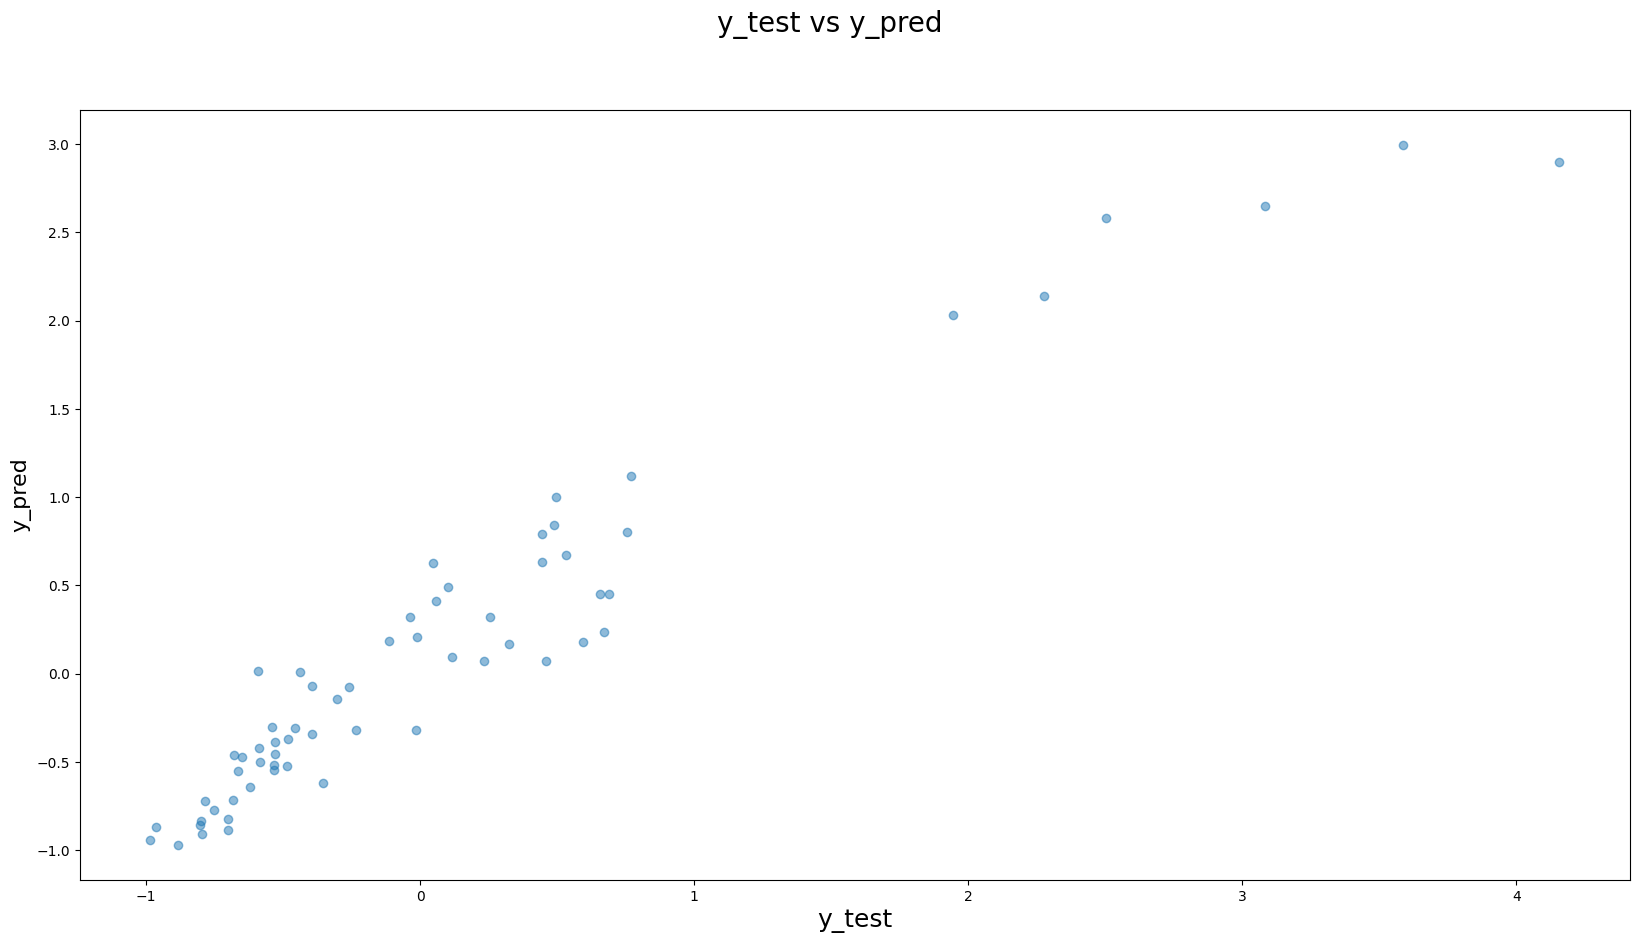

In [156]:
fig = plt.figure(figsize=(20,10))
plt.scatter(y_test, y_pred, alpha=.5)
fig.suptitle('y_test vs y_pred', fontsize = 20)              
plt.xlabel('y_test', fontsize = 18)                          
plt.ylabel('y_pred', fontsize = 16) 
plt.show()

In [204]:
lasso = Lasso()
param_grid = {
    "alpha": np.logspace(-3, 3, 20)
}
model1=GridSearchCV(estimator=lasso,param_grid=param_grid,cv=5)  # Tune alpha as needed
model1.fit(X_train, y_train)

# 🔹 Predict
y_pred_lasso = model1.predict(X_test)
y_pred_train=model1.predict(X_train)
# 🔹 Evaluation
print("Training Accuracy:", r2_score(y_train, y_pred_train))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R² Score:", r2_score(y_test, y_pred_lasso))
print("Lasso Coefficients:", model1.best_estimator_.coef_)
print("MAE",mean_absolute_error(y_test,y_pred_lasso))

Training Accuracy: 0.9526155515824973
MSE: 0.1031120233172419
R² Score: 0.9108840265998528
Lasso Coefficients: [-0.         -0.          0.22571654 -0.0329688   0.24534833  0.12843233
 -0.         -0.00250059  0.          0.12419749  0.02654542  0.
  0.          0.0354514   0.25342129  0.16119533  0.         -0.00645863
 -0.00672559  0.01239189  0.12364562  0.          0.         -0.0610257
 -0.01013963 -0.04513465 -0.00409769  0.06822864 -0.02968399  0.01842373
 -0.03300467 -0.02618344  0.          0.06344282 -0.02177643  0.00901007
  0.         -0.         -0.02711819 -0.         -0.01180546 -0.02658586
  0.01629909  0.11924316  0.         -0.          0.         -0.
 -0.          0.00438539 -0.         -0.         -0.          0.0388129
 -0.00897322  0.00544309 -0.         -0.          0.00565936  0.
  0.         -0.          0.         -0.         -0.          0.02879292
 -0.         -0.04787162]
MAE 0.22803484597720677


Here R^2 suggests 91% proportion of variation is explained by regressor variables.


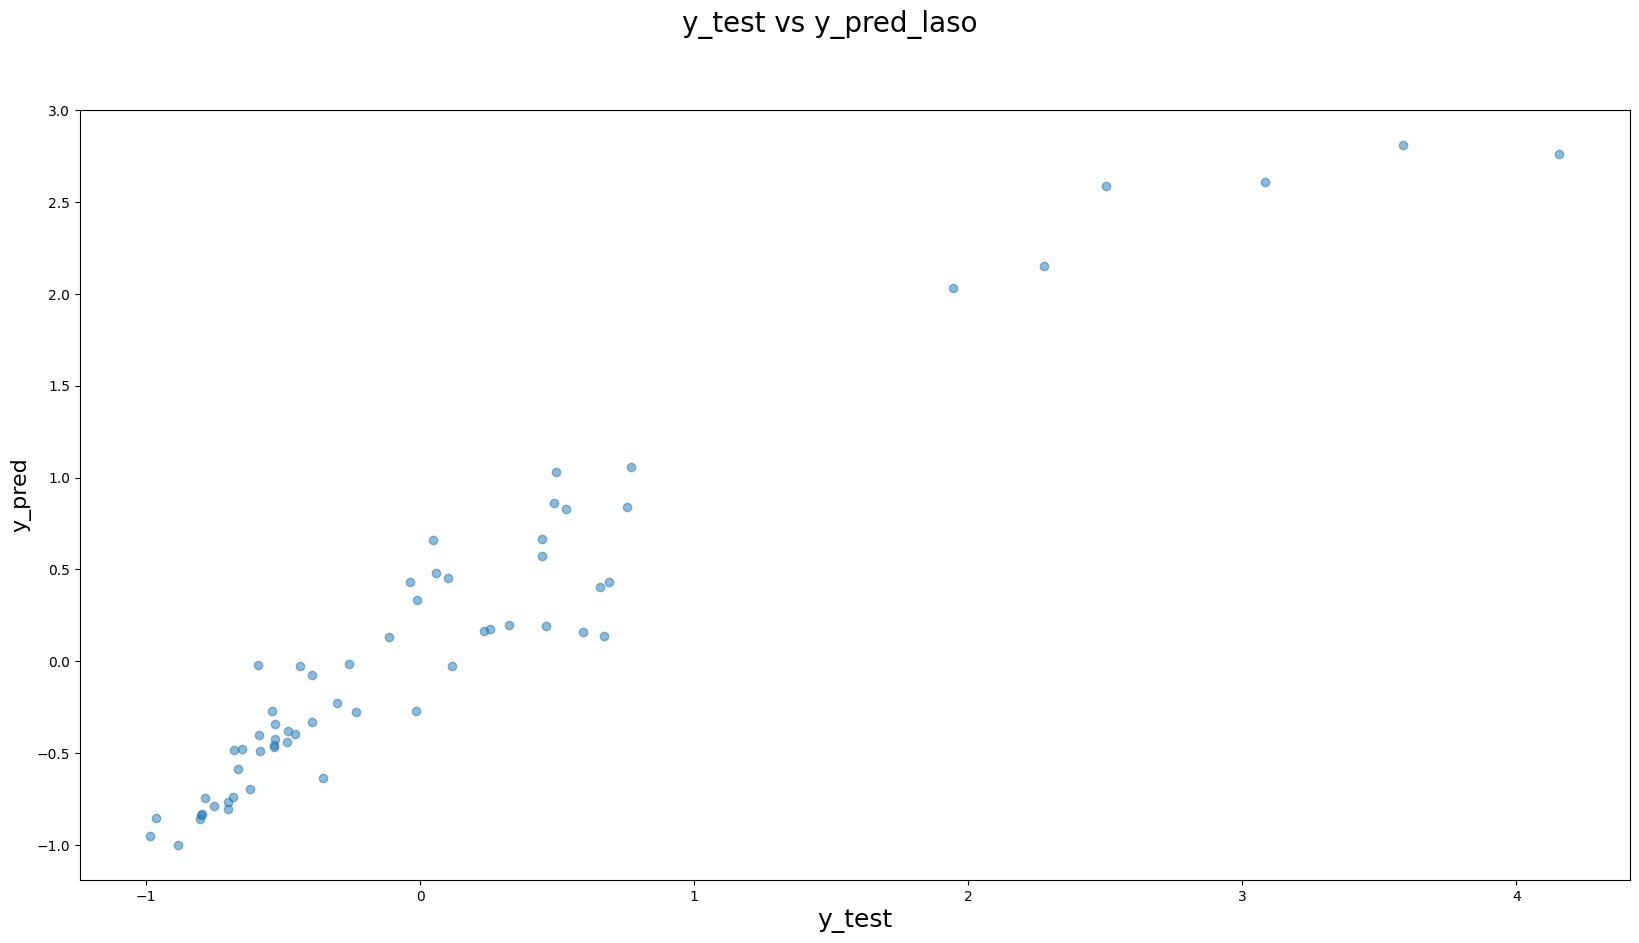

In [ ]:
fig = plt.figure(figsize=(20,10))
plt.scatter(y_test, y_pred_lasso, alpha=.5)
fig.suptitle('y_test vs y_pred_lasso', fontsize = 20)               
plt.xlabel('y_test', fontsize = 18)                          
plt.ylabel('y_pred_lasso', fontsize = 16) 
plt.show()

*Conclusion*

We compare this two model Ridge and Lasso with some metrics R^2,MSE,MAE. we saw Ridge regression is very much better than Lasso regression.


Convert the  dataframe into original scale using better model.

In [187]:
y_pred=pd.DataFrame(y_pred_ridge,columns=["Predicted_Price"])
y_pred
y_test=pd.DataFrame(y_test,columns=["Actual_Price"])
y_test

,Actual_Price
0,-0.683619
1,-0.586315
2,-0.541326
3,-0.483097
4,-0.700972
...,...
57,-0.531557
58,-0.011870
59,-0.678863
60,-0.354943


In [189]:
y_pred_original = Scaler.inverse_transform(y_pred)
y_test_original= Scaler.inverse_transform(y_test)
print("Predicted Prices (Original Scale):", pd.DataFrame(y_pred_original))
print("Actual Prices (Original Scale):", pd.DataFrame(y_test_original))

Predicted Prices (Original Scale):                0
0    7491.773639
1    9795.298243
2   10700.015019
3   10197.428271
4    6168.196635
..           ...
57   8808.761101
58  14675.656127
59   9487.687220
60   8239.117583
61  33671.384756

[62 rows x 1 columns]
Actual Prices (Original Scale):           0
0    7738.0
1    8495.0
2    8845.0
3    9298.0
4    7603.0
..      ...
57   8921.0
58  12964.0
59   7775.0
60  10295.0
61  37028.0

[62 rows x 1 columns]


Now we check that Ridge regression is follows my assumption or not.

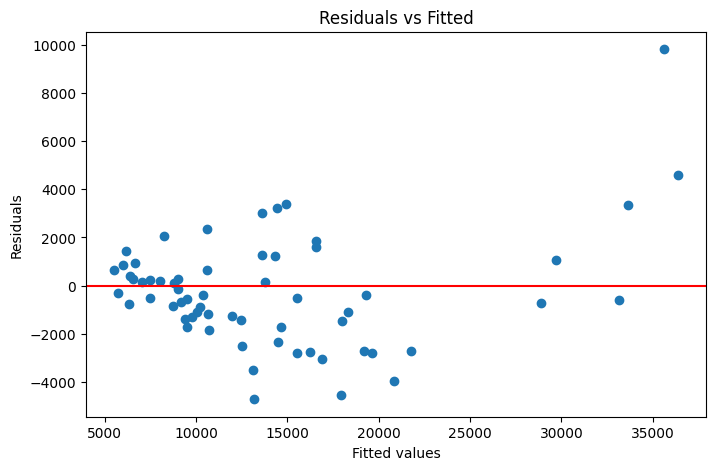

In [191]:
residuals = y_test_original - y_pred_original
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_original, residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

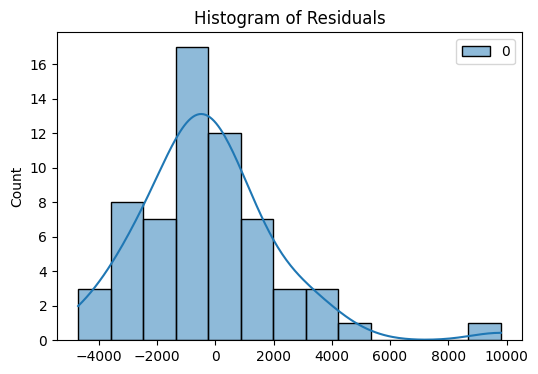

In [192]:
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.show()

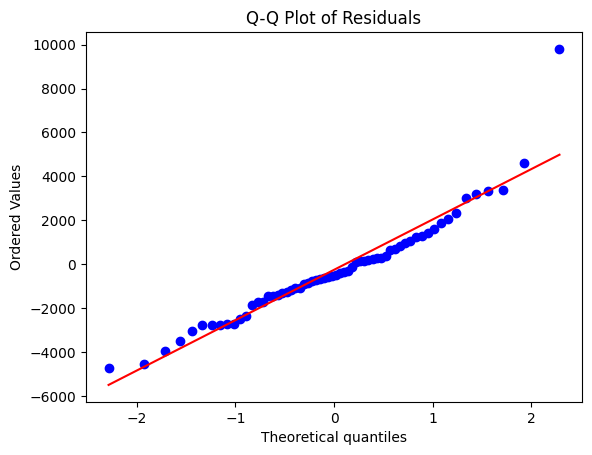

In [200]:
residuals = residuals.flatten()

probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

The residuals vs fitted plot shows a random scatter around zero, indicating that the assumptions of linearity and constant variance are satisfied for the Ridge regression model.

The histogram shows a bell-shaped, symmetric distribution centered around zero. This indicates that the residuals are approximately normally distributed, with no significant skewness or heavy tails.

The Q-Q plot shows that most of the residuals lie close to the reference line, with only minor deviations at the tails. This further confirms that the residuals follow a nearly normal distribution.

Both the histogram and the Q-Q plot suggest that the **normality assumption of residuals is well satisfied**, making the linear(Ridge) regression model appropriate for inference.
